# **Notebook 2: B-Raf Kinase Domain Molecular Docking Analysis using GNINA**



## **Project Overview**

This notebook implements an automated structural biology pipeline to perform high-resolution molecular docking on the human B-Raf kinase domain. Starting with an 3D structural model generated via AlphaFold, the pipeline handles protein coordinate transformation, computational ligand generation, and runs the deep learning-driven GNINA docking engine to map and evaluate small-molecule binding interactions.

## **Methodological Workflow**

**1. Environment & Dependency Configuration:**

Initializing core cheminformatics and structural biology libraries (RDKit, Biopython, py3Dmol) alongside the deployment of the compiled GNINA (v1.0.3) neural network docking binary.


**2. Receptor Structural Preparation:**

Parsing the native high-fidelity AlphaFold structural coordinate file (.cif) and programmatically converting it into a standard Protein Data Bank (.pdb) format optimized for spatial grids.

**3. De Novo Ligand Generation:**

Utilizing RDKit to construct a structurally optimized, explicitly hydrogenated, and energy-minimized 3D conformation of the target inhibitor directly from its canonical SMILES descriptor.

**4. Molecular Docking:**

Executing an unbiased, full-surface blind docking simulation across the receptor coordinates (--autobox_ligand) using GNINA’s hybrid scoring metrics, which combine classical empirical force fields with Convolutional Neural Networks (CNNs).

**5 & 6. Affinity Profiles & Interactivity:**

Rendering interactive 3D structural topologies and evaluating the thermodynamic stability and geometric validity of top-scoring binding poses.

## **Ligand Selection:**- Dabrafenib

To rigorously evaluate the binding pocket of our AlphaFold-derived B-Raf model, Dabrafenib (PubChem CID: 44462760) was selected as the interaction probe based on several distinct criteria:

**High-Specificity Molecular Match:**
Dabrafenib is a potent, ATP-competitive small-molecule tyrosine kinase inhibitor explicitly developed to target the active conformation of the human B-Raf kinase domain.

**Clinical and Oncological Relevance:**
As a highly effective therapeutic approved for the treatment of advanced malignancies driven by oncogenic BRAF mutations (such as metastatic melanoma and non-small cell lung cancer), it represents a critical landmark compound in precision oncology.

**Robust Computational Positive Control:**
Because Dabrafenib displays a well-documented, high-affinity binding profile to native human B-Raf in vivo, it serves as an ideal benchmarking control. Achieving a strongly favorable, negative Gibbs free energy of binding ($\Delta G$ in kcal/mol) and a high CNN spatial confidence score computationally confirms that our un-liganded, machine-learning-predicted receptor maintains a biologically faithful and functional orthosteric binding pocket.

### **1. Environment Setup and Library Installation**

In [4]:
# To install every single external library required for data, docking, and rendering
!pip install rdkit -q
!pip install biopython -q
!pip install py3Dmol -q
!pip install matplotlib numpy -q

# To download the exact GNINA engine binary
!wget -q https://github.com/gnina/gnina/releases/download/v1.0.3/gnina
!chmod +x gnina

# To verify installation immediately
!./gnina --version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 50.0 MB/s eta 0:00:00
gnina  master:e9cb230+   Built Feb 11 2023.


### **2. Protein Structure Conversion (CIF to PDB)**

This parses the AlphaFold structural coordinates from the native .cif output format and converts them into a standard .pdb file to ensure full compatibility with the GNINA docking engine. First you have to ensure your AlphaFold structure file is uploaded to your panel before running.

In [2]:
from Bio.PDB import MMCIFParser, PDBIO

# To initialize the structural parser
parser = MMCIFParser(QUIET=True)
structure = parser.get_structure("BRAF", "fold_braf_structure.cif")

# To write out the parsed structural coordinates as a standard PDB file
io = PDBIO()
io.set_structure(structure)
io.save("BRAF_model.pdb")

print("Converted to PDB successfully!")

Converted to PDB successfully!


### **3. Ligand Preparation and 3D Generation via RDKit**

This helps generate a reliable, energy-minimized 3D structural conformation of the target inhibitor drug (Dabrafenib) directly from its canonical SMILES string descriptor using RDKit's embedding algorithms.

In [5]:
from rdkit import Chem
from rdkit.Chem import AllChem

# Canonical SMILES representation of the target inhibitor (Ligand-Dabrafenib)
smiles = "CC1=C(C(=CS1)C2=NC(=NC=C2)N)C3=C(C(=CC=C3)NS(=O)(=O)C4=C(C=CC=C4F)F)C(F)(F)F"

# Convert SMILES to molecule object, add explicit hydrogen atoms, and build 3D coordinates
mol = Chem.MolFromSmiles(smiles)
mol_with_h = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol_with_h, AllChem.ETKDGv3())
AllChem.MMFFOptimizeMolecule(mol_with_h)

# Export the optimized 3D structure to a standard Structure Data File (SDF)
writer = Chem.SDWriter("dabrafenib_ligand.sdf")
writer.write(mol_with_h)
writer.close()

print("Ligand dabrafenib_ligand.sdf generated successfully!")

Ligand dabrafenib_ligand.sdf generated successfully!


### **4. Molecular Docking Simulation (GNINA Execution)**

This section executes the molecular docking engine using blind docking boundaries centered around the entire surface of the converted protein PDB structure (--autobox_ligand). The pipeline configurations applied are: an exhaustiveness rating of 8 , capturing the top 9 binding modes , using a fixed random seed of 42 for reproducibility.

In [6]:
!./gnina \
  --receptor BRAF_model.pdb \
  --ligand dabrafenib_ligand.sdf \
  --autobox_ligand BRAF_model.pdb \
  --out docking_output.sdf \
  --exhaustiveness 8 \
  --num_modes 9 \
  --seed 42

              _             
             (_)            
   __ _ _ __  _ _ __   __ _ 
  / _` | '_ \| | '_ \ / _` |
 | (_| | | | | | | | | (_| |
  \__, |_| |_|_|_| |_|\__,_|
   __/ |                    
  |___/                     

gnina  master:e9cb230+   Built Feb 11 2023.
gnina is based on smina and AutoDock Vina.
Please cite appropriately.

Recommend running with single model (--cnn crossdock_default2018)
or without cnn scoring (--cnn_scoring=none).

Commandline: ./gnina --receptor BRAF_model.pdb --ligand dabrafenib_ligand.sdf --autobox_ligand BRAF_model.pdb --out docking_output.sdf --exhaustiveness 8 --num_modes 9 --seed 42
Using random seed: 42

0%   10   20   30   40   50   60   70   80   90   100%
|----|----|----|----|----|----|----|----|----|----|
***************************************************
 | pose 0 | initial pose not within box

mode |  affinity  |    CNN     |   CNN
     | (kcal/mol) | pose score | affinity
-----+------------+------------+----------
    1       -9.

### **5. 3D Structural Visualization of Target Protein**

This help render a fast 3D interactive ribbon model of target protein structure directly within the notebook to confirm structural integrity.

In [7]:
import py3Dmol

# To read the generated protein PDB data
with open("BRAF_model.pdb") as f:
    pdb_data = f.read()

# To initialize and render the interactive 3D ribbon viewer
view = py3Dmol.view(width=800, height=500)
view.addModel(pdb_data, "pdb")
view.setStyle({"cartoon": {"color": "spectrum"}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### **6. Data Analysis and Visualization of Docking Affinities**

This code extracts the calculated binding energies ($kcal/mol$) across all simulated structural conformations and renders a high-resolution bar chart. The highest-affinity conformation (Mode 1) is dynamically highlighted to provide a clear, presentation-ready comparison of the binding landscapes.

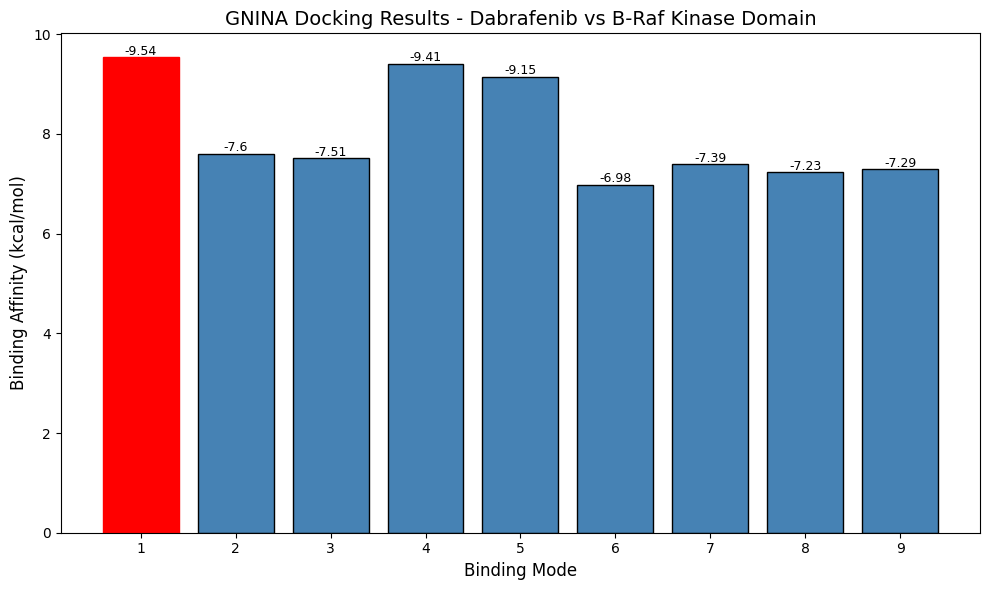

Plot saved!


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Input your explicit GNINA results
modes = [1, 2, 3, 4, 5, 6, 7, 8, 9]
affinities = [-9.54, -7.60, -7.51, -9.41, -9.15, -6.98, -7.39, -7.23, -7.29]

# 2. Configure the plotting frame
plt.figure(figsize=(10, 6))
bars = plt.bar(modes, [abs(a) for a in affinities], color='steelblue', edgecolor='black')

# 3. Highlight your best binding mode (Mode 1 is index 0) in red
bars[0].set_color('red')

# 4. Label axes and title precisely
plt.xlabel('Binding Mode', fontsize=12)
plt.ylabel('Binding Affinity (kcal/mol)', fontsize=12)
plt.title('GNINA Docking Results - Dabrafenib vs B-Raf Kinase Domain', fontsize=14)
plt.xticks(modes)

# 5. Add value labels on top of each bar
for i, v in enumerate(affinities):
    plt.text(i+1, abs(v)+0.05, str(v), ha='center', fontsize=9)

# 6. Optimize, save, and render
plt.tight_layout()
plt.savefig('/content/docking_results.png', dpi=150)
plt.show()

print("Plot saved!")